# Use Case – Knowledge Graph Operational Restore

This notebook runs the same data and scenario as `Use_Case_sample.ipynb` but uses the
**graph-aware dependency path** to demonstrate that substations are correctly returned to
operational status after repair.  The key difference from the original notebook is:

1. `config['dependency_parameters']['knowledge_graph']` is populated with explicit rules
   for `msls`/`ms`/`ls` substations (loaded from the default knowledge graph).
2. `evaluate_dependencies_from_graph` performs a two-pass evaluate: **restore** eligible
   assets first, then **block** assets that still do not meet conditions.
3. A per-timestep diagnostic cell shows operational counts so the recovery is observable.

In [1]:
# HIDE CODE
# Imports
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx

from src.adaptation import simulate_asset_damage_recovery_access_breakdown_ema
from config import get_config, get_development_config, setup_dev_directories, get_simulation_params
from src.simulation import simulate_asset_damage_recovery_access_breakdown 
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.caching import load_simulation_caches
from pathlib import Path
from src.impacts import create_voronoi_for_asset_type, prepare_population_impact_data, prepare_land_use_impact_data, update_voll_rates, prepare_land_use_impact_data
import pickle
from src.visualisations import *
from ema_workbench import Model, RealParameter, IntegerParameter, Constant, TimeSeriesOutcome, SequentialEvaluator, Samplers, ema_logging, Policy

c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")


In [2]:
# Set up configuration
config = get_development_config() #get_config() gets parameters directly from config.py in root, development config uses sample data
# config = get_config()
setup_dev_directories(config, remove_cache=False) # For a clean run, set remove_cache=True to clear all caches and start fresh
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']

# Configure simulation parameters from config
simulation_params = get_simulation_params(config) 
accessibility_model = None
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")

# 6 for full data, 24 for sample data (which has 24 timesteps per day instead of 4)
config['simulation_config']['major_timestep'] = 24
# config['simulation_config']['major_timestep'] = 6
config['simulation_config']['verbose'] = False
max_days = None

caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

root_dir = Path(config['root_dir'])
study_area_path = root_dir / 'data' / 'utilities' / 'stedin_area.geojson'
land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1_sample.gpkg'
# land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1.gpkg'
population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1_sample.gpkg"
# population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1.gpkg"

print(f"WARNING! Values of lost load should be calculated with country-wide VOLL rates, not sample data!")

# Cache path for asset_to_lu (the complete pre-computed lookup)
asset_to_lu_cache_path = config['interim_dir'] / f"{land_use_path.stem}_asset_to_lu.pkl"

Created directories: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps, c:\repos\powerpath\powerpath\data\output\output_test_hazard_timesteps

Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  verbose: True
  recovery_parameters: {'repair_time_coefficients': [702.72, 3.14, 1.9891], 'damage_ratio_coefficients': (0.0468, 0.0077), 'damage_threshold': 0.01, 'repair_threshold': 2.0}
  accessibility_model: None

Directory structure:
  Interim: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps
  Output: c:\repos\powerpath\powerpath\data\output\output_test_hazard_timesteps
  Cache will be organized by hazard directory: test_hazard_timesteps
Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\powerpath\powerpath\data

Found 10 hazard map files


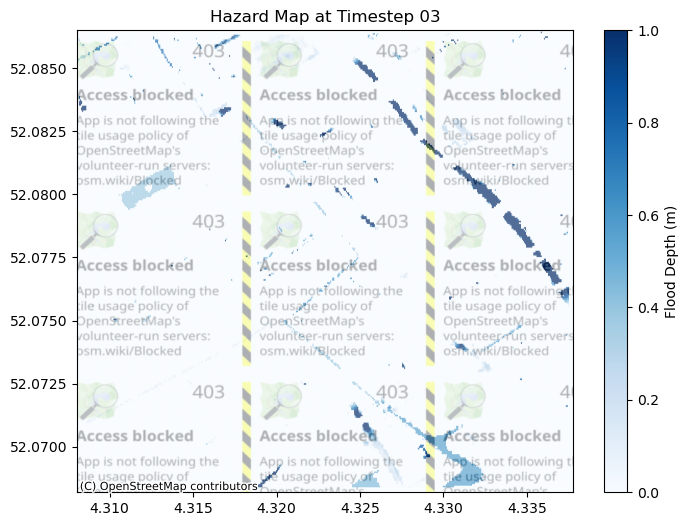

In [3]:
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  
hazard_map_03 = hazard_maps[3]
with rasterio.open(hazard_map_03) as src:
    hazard_data_03 = src.read(1)
    hazard_transform_03  = src.transform
    crs = src.crs


from rasterio.plot import plotting_extent

fig, ax = plt.subplots(figsize=(8, 6))
extent = plotting_extent(hazard_data_03, hazard_transform_03)
im = ax.imshow(hazard_data_03, cmap='Blues', vmax=1, extent=extent, origin='upper', zorder=1)
ax.set_title("Hazard Map at Timestep 03")
fig.colorbar(im, ax=ax, label="Flood Depth (m)")

# Set axis to Web Mercator for contextily
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_aspect('auto')
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, alpha=0.3,zorder=2)
plt.show()

Found 1 electricity station files matching types ['msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['msls_stations_test_samples.shp']
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 245 electricity assets
Asset types: {'msls': 245}


C:\Users\peregrin\AppData\Local\Temp\ipykernel_10252\1530913130.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_assets.centroid.to_crs(epsg=4326).plot(ax=ax, color='green',


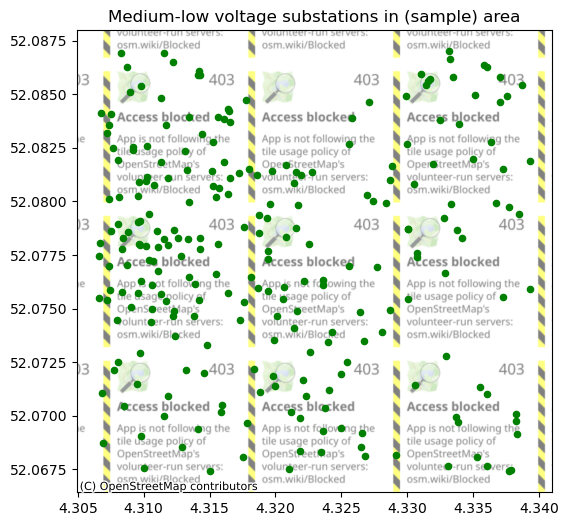

In [4]:
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['msls'])
fig, ax = plt.subplots(figsize=(8, 6))
gdf_assets.centroid.to_crs(epsg=4326).plot(ax=ax, color='green', 
                                        #    markersize=2)
                                          markersize=20)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.OpenStreetMap.Mapnik, zoom=15, alpha=0.5)
plt.title("Medium-low voltage substations in (sample) area")
plt.show()

## Hospital Assets and KG Service-Area Interdependence

We now extend the simulation to include hospitals as a second asset type.  Key design decisions:

* **Voronoi association** – each hospital is linked to the substation whose Voronoi service polygon contains it.  This mapping is computed **once** before the simulation loop and stored as the `service_area_map`.
* **Power-loss disruption** – if *all* substations a hospital depends on are non-operational, the hospital is also non-operational.  With Voronoi each hospital maps to exactly one substation.
* **Immediate return** – once the substation is operational again the hospital returns to operational immediately (no hospital-specific repair needed for this disruption mode).
* **Direct flood damage** – hospitals are also overlaid with the flood maps using a placeholder `hospital_fragility_function` (to be calibrated with evidence-based depth-damage data).
* **Separate repair crews** – `repair_crews_by_asset_type={'hospital': 2}` keeps hospital and substation crews independent.

In [ ]:
from src.impacts import create_voronoi_for_asset_type, create_voronoi_boundary
from src.utils import compile_asset_gdfs, build_voronoi_service_area_map
import geopandas as gpd
from shapely.geometry import Point

# ── (a) Create synthetic hospital polygons from provided centroids (EPSG:28992) ──
hospital_specs = [
    {
        'name': 'Hospital_flooded_disrupted_voronoi',
        'centroid_xy': (81794.99, 454857.87),
        'expected_state': 'flooded_and_disrupted_voronoi',
    },
    {
        'name': 'Hospital_not_flooded_disrupted_voronoi',
        'centroid_xy': (82780.77, 455496.61),
        'expected_state': 'not_flooded_but_disrupted_voronoi',
    },
    {
        'name': 'Hospital_not_flooded_not_disrupted_voronoi',
        'centroid_xy': (82486.8, 455026.8),
        'expected_state': 'not_flooded_not_disrupted_voronoi',
    },
]

gdf_hospitals = gpd.GeoDataFrame(
    {
        'type': ['hospital'] * len(hospital_specs),
        'name': [h['name'] for h in hospital_specs],
        'expected_state': [h['expected_state'] for h in hospital_specs],
    },
    geometry=[Point(*h['centroid_xy']).buffer(15) for h in hospital_specs],
    crs='EPSG:28992',
).to_crs('EPSG:4326')

print(f"Created {len(gdf_hospitals)} synthetic hospital polygons (15m buffer)")
print(gdf_hospitals[['name', 'expected_state']])

# ── (b) Compile combined gdf_assets ───────────────────────────────────────────
# compile_asset_gdfs concatenates and resets the index so that row positions
# are the stable identifiers used throughout the simulation and the Voronoi map.
gdf_assets_combined = compile_asset_gdfs([gdf_assets, gdf_hospitals])

substation_positions = list(gdf_assets_combined[gdf_assets_combined['type'] == 'msls'].index)
hospital_positions   = list(gdf_assets_combined[gdf_assets_combined['type'] == 'hospital'].index)
print(f"Combined gdf_assets: {len(gdf_assets_combined)} assets")
print(f"  Substation positions: {substation_positions}")
print(f"  Hospital positions:   {hospital_positions}")

In [ ]:
# ── (c) Build Voronoi from the combined gdf_assets (msls slice) ───────────────
# create_voronoi_for_asset_type uses gdf_assets_combined.index as asset_id values
# so they match the positional indices in the combined array.
boundary = create_voronoi_boundary(gdf_assets_combined[gdf_assets_combined['type'] == 'msls'])
voronoi_gdf = create_voronoi_for_asset_type(gdf_assets_combined, 'msls', boundary=boundary)
print(f"Built {len(voronoi_gdf)} Voronoi polygons")
print(f"Voronoi asset_ids (substation positions): {voronoi_gdf['asset_id'].tolist()}")

# ── (d) Associate hospitals with their supplying substation via Voronoi ────────
# build_voronoi_service_area_map uses the R-tree spatial index (bounding-box
# candidate filter) then a fine geometric intersection.
# This search runs ONCE before the simulation; the result is reused every timestep.
gdf_hospitals_proj = gdf_assets_combined[gdf_assets_combined['type'] == 'hospital'].to_crs(voronoi_gdf.crs)
service_area_map = build_voronoi_service_area_map(voronoi_gdf, gdf_hospitals_proj)

print(f"\nService-area map {{substation_pos: [hospital_pos, ...]}}:")
for k, v in service_area_map.items():
    print(f"  Substation {k} → hospitals {v}")

unmatched = [p for p in hospital_positions if not any(p in vs for vs in service_area_map.values())]
if unmatched:
    print(f"\nWarning: {len(unmatched)} hospital(s) outside all Voronoi polygons: {unmatched}")

In [ ]:
# ── Inject hospital KG rules and service_area_map into the simulation config ──
from src.dependency_knowledge_graph import build_default_knowledge_graph

# build_default_knowledge_graph() now includes:
#   • hospital direct flood rule  (trigger=repair_complete)
#   • msls → hospital service-area rule  (trigger=immediate)
kg_hospital = build_default_knowledge_graph()
print(f"Loaded knowledge graph with {len(kg_hospital)} rules")
for rule in kg_hospital._rules:
    rto = rule.return_to_operational
    desc = rto.trigger if rto.trigger != 'repair_below' else f'{rto.trigger} ({rto.threshold}h)'
    b = f" → {rule.asset_type_b}" if rule.asset_type_b else ""
    print(f"  [{rule.relationship}] {rule.asset_type_a}{b}: blocks={rule.hazard_blocks_operation}, rto={desc}")

config['dependency_parameters']['knowledge_graph'] = [r.to_dict() for r in kg_hospital._rules]
config['dependency_parameters']['service_area_map'] = service_area_map
print(f"\nservice_area_map injected: {bool(service_area_map)}")

## Simulation Run with Hospitals

`gdf_assets_combined` (substations + hospitals) is passed alongside:
- the updated `config` with hospital KG rules and `service_area_map`
- `repair_crews_by_asset_type={'hospital': 2}` for 2 dedicated hospital repair crews

## Knowledge Graph Configuration

We load the default knowledge graph and inject it into the simulation config.
The graph encodes:

| Asset type | Return-to-operational trigger |
|---|---|
| `msls` | `repair_complete` – full repair must finish |
| `ms`   | `repair_complete` – full repair must finish |
| `ls`   | `repair_below 2h` – re-energised once remaining work < 2 hours |

This replaces the ad-hoc `state.operational[completed_repairs] = True` fix with a
principled, config-driven two-pass evaluation (restore then block).

In [5]:
from src.dependency_knowledge_graph import build_default_knowledge_graph, TRIGGER_REPAIR_COMPLETE, TRIGGER_REPAIR_BELOW

kg = build_default_knowledge_graph()
print(f'Loaded knowledge graph with {len(kg)} rules')
for rule in kg._rules:
    rto = rule.return_to_operational
    desc = rto.trigger if rto.trigger != 'repair_below' else f'{rto.trigger} (threshold={rto.threshold}h)'
    print(f'  {rule.asset_type_a}: hazard_blocks={rule.hazard_blocks_operation}, return_to_operational={desc}')

# Inject knowledge graph rules into the simulation config so the graph-aware path is active.
# get_development_config() already populates this from config.py; this cell makes it explicit.
print(f"\nKnowledge graph rules in config: {len(config['dependency_parameters']['knowledge_graph'])} entries")
print(f"Hazard type: {config['dependency_parameters']['hazard_type']}")

Loaded knowledge graph with 3 rules
  msls: hazard_blocks=True, return_to_operational=repair_complete
  ms: hazard_blocks=True, return_to_operational=repair_complete
  ls: hazard_blocks=True, return_to_operational=repair_below (threshold=2.0h)

Knowledge graph rules in config: 3 entries
Hazard type: flooding


## Single Simulation Run (graph-aware path)

We run the same simulation as the original notebook.  Because `dependency_parameters`
is now populated, `_update_operational_state` takes the graph-aware path:

1. **Restore pass**: re-enables substations that are no longer flooded and have
   completed (or sufficiently completed) repair.
2. **Block pass**: immediately re-suppresses any substation that is still flooded
   or whose repair trigger has not yet been met.

Both passes are driven by `evaluate_dependencies_from_graph` in `dependency_evaluator.py`.

In [6]:
caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])

all_results, final_state, cache_updated = simulate_asset_damage_recovery_access_breakdown(
    gdf_assets_combined,      # combined substations + hospitals
    hazard_maps,
    number_repair_crews=5,    # substation repair crews
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=simulation_params['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=False,
    timestep_output=True,
    execution_id='kg_hospital_run',
    config=config,
    major_timestep=config['simulation_config']['major_timestep'],
    accessibility_cache=caches.get('accessibility_cache', None),
    hazard_extraction_cache=caches.get('hazard_extraction_cache', None),
    overlap_cache=caches.get('overlap_cache', None),
    island_cache=caches.get('island_cache', None),
    repair_crews_by_asset_type={'hospital': 2},  # dedicated hospital repair crews
)

Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
No island cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\island_cache_test_hazard_timesteps.pkl
Identified 16 boundary assets out of 245 total assets.
Extracting hazard values using method: max
Saved hazard extraction cache: 1 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
Cached hazard extraction results for map 0 from GHG_timesteps_test0.tif
Cache miss for island_assignment_EV0_ma_0.2_n245_ffb9075134a2efe7ad5cdcebb95eef31, computing islands on the fly...
Loading hazard graph from c:\repos\powerpath\powerpath\data\test_samples\sta

In [7]:
from src.visualisations import print_simulation_summary
results_df = pd.DataFrame(all_results[0][1])
print_simulation_summary(results_df, gdf_assets_combined, config)

SIMULATION RESULTS SUMMARY
Total assets: 245
Simulation duration: 240 hours (10 days)
Final operational rate: 100.0%
Peak damaged assets: 6
Peak flooded assets: 6
Total crew assignments: 16

RECOVERY TIMELINE (Daily Summary)
Day 0: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 1: 98.0% operational, 5 flooded, 0 unreachable, 5 damaged.
Day 2: 97.6% operational, 6 flooded, 0 unreachable, 6 damaged.
Day 3: 98.0% operational, 5 flooded, 0 unreachable, 5 damaged.
Day 4: 99.2% operational, 2 flooded, 0 unreachable, 2 damaged.
Day 5: 99.2% operational, 2 flooded, 0 unreachable, 2 damaged.
Day 6: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 7: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 8: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.
Day 9: 100.0% operational, 0 flooded, 0 unreachable, 0 damaged.

REPAIR BACKLOG ANALYSIS
Hour | Flooded | Damaged | Crews | Backlog | Effective?
-------------------------------------------------------
 0.

## Operational Restoration Diagnostic

The plot below shows the number of operational substations over time.
Under the graph-aware path, substations that are repaired and no longer flooded
should return to `operational = True`.  You should see the operational count
recover toward the total asset count as the flood recedes and repair crews finish.

If the count stays flat (never recovers), the restore pass is not working.
If it recovers, the two-pass design is functioning correctly.

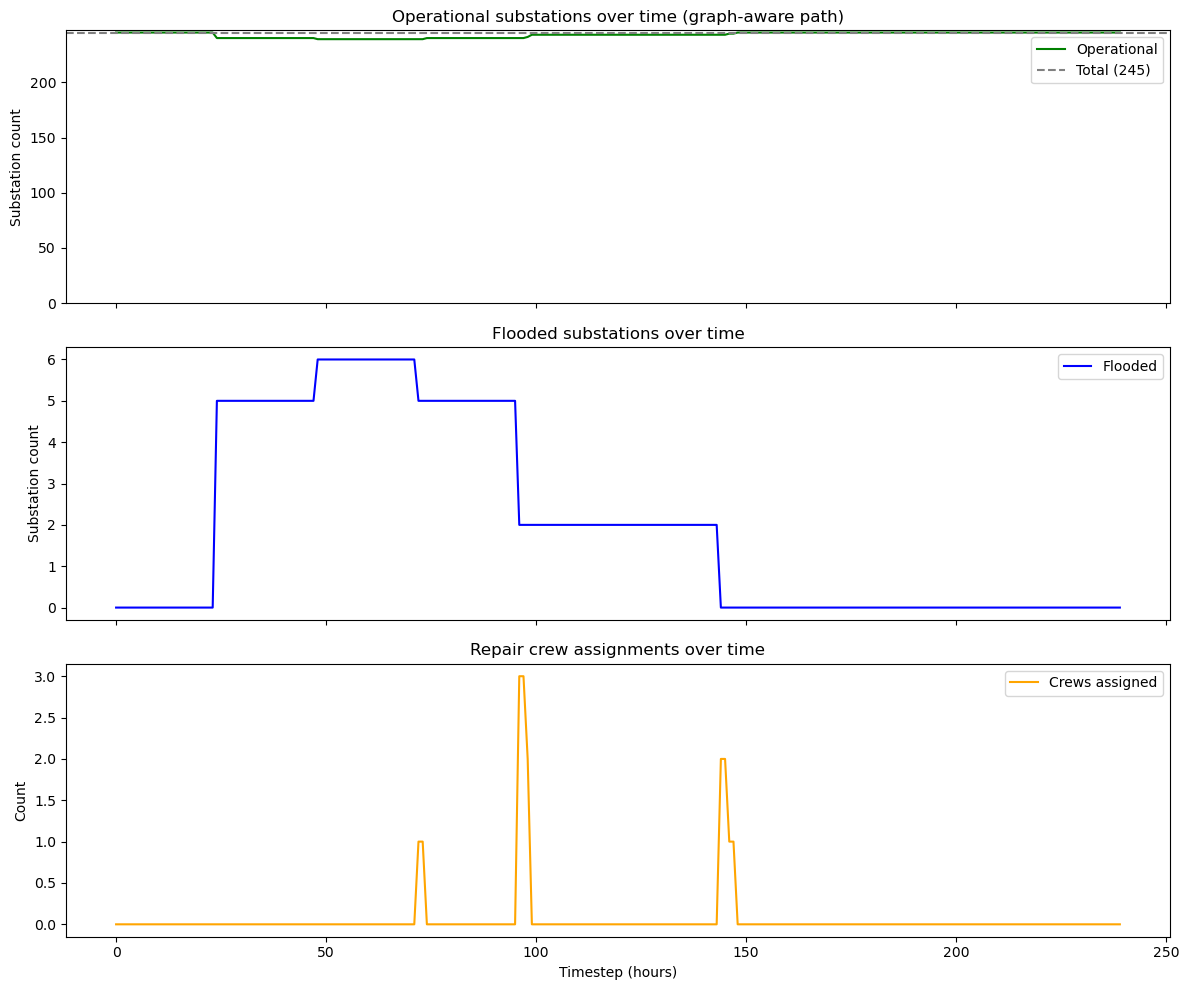

Operational loss window: timestep 24 to 147
Minimum operational count: 239 / 245
Full operational recovery confirmed.


In [15]:
# Plot operational/flooded/crew counts by asset type from timestep-level arrays
import numpy as np

asset_type_values = gdf_assets_combined['type'].astype(str).to_numpy()
asset_types = sorted(set(asset_type_values))
asset_positions_by_type = {atype: np.where(asset_type_values == atype)[0] for atype in asset_types}
timestep_results = all_results[0][2]  # per-timestep detail records (list of dicts)

if timestep_results:
    rows = []
    for d in timestep_results:
        rd = {'timestep': d['timestep']}
        operational = np.asarray(d['operational']) if 'operational' in d else None
        flooded = np.asarray(d['flooded']) if 'flooded' in d else None

        if 'crew_assigned' in d:
            crew_assigned = np.asarray(d['crew_assigned'])
        elif 'crews_assigned_count' in d:
            crew_assigned = None
            rd['crews_assigned_total'] = int(d['crews_assigned_count'])
        else:
            crew_assigned = None

        for atype, positions in asset_positions_by_type.items():
            if operational is not None:
                rd[f'operational_{atype}'] = int(operational[positions].sum())
            if flooded is not None:
                rd[f'flooded_{atype}'] = int(flooded[positions].sum())
            if crew_assigned is not None:
                rd[f'crews_assigned_{atype}'] = int(crew_assigned[positions].sum())

        rows.append(rd)

    ts_df = pd.DataFrame(rows)
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Operational by asset type
    for atype in asset_types:
        col = f'operational_{atype}'
        if col in ts_df.columns:
            axes[0].plot(ts_df['timestep'], ts_df[col], label=f'{atype} operational')
            axes[0].axhline(len(asset_positions_by_type[atype]), linestyle='--', alpha=0.25)
    axes[0].set_ylabel('Count')
    axes[0].set_title('Operational assets by type')
    axes[0].legend()

    # Flooded by asset type
    flooded_cols = [f'flooded_{atype}' for atype in asset_types if f'flooded_{atype}' in ts_df.columns]
    if flooded_cols:
        for atype in asset_types:
            col = f'flooded_{atype}'
            if col in ts_df.columns:
                axes[1].plot(ts_df['timestep'], ts_df[col], label=f'{atype} flooded')
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'No flooded data', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_ylabel('Count')
    axes[1].set_title('Flooded assets by type')

    # Crew assignments by asset type
    crew_cols = [f'crews_assigned_{atype}' for atype in asset_types if f'crews_assigned_{atype}' in ts_df.columns]
    if crew_cols:
        for atype in asset_types:
            col = f'crews_assigned_{atype}'
            if col in ts_df.columns:
                axes[2].plot(ts_df['timestep'], ts_df[col], label=f'{atype} crews assigned')
        axes[2].legend()
    elif 'crews_assigned_total' in ts_df.columns:
        axes[2].plot(ts_df['timestep'], ts_df['crews_assigned_total'], label='Total crews assigned', color='orange')
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, 'No crew assignment data', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_ylabel('Count')
    axes[2].set_title('Repair crew assignments by type')

    axes[-1].set_xlabel('Timestep (hours)')
    plt.tight_layout()
    plt.show()

    print('Final reporting by asset type:')
    final_row = ts_df.iloc[-1]
    for atype in asset_types:
        op_col = f'operational_{atype}'
        fl_col = f'flooded_{atype}'
        cr_col = f'crews_assigned_{atype}'
        total_for_type = len(asset_positions_by_type[atype])
        op_text = f"operational={int(final_row[op_col])}/{total_for_type}" if op_col in ts_df.columns else 'operational=n/a'
        fl_text = f"flooded={int(final_row[fl_col])}/{total_for_type}" if fl_col in ts_df.columns else 'flooded=n/a'
        cr_text = f"crews_assigned={int(final_row[cr_col])}" if cr_col in ts_df.columns else 'crews_assigned=n/a'
        print(f"  {atype}: {op_text}, {fl_text}, {cr_text}")
else:
    print('No timestep-level results available. Re-run with timestep_output=True.')

In [14]:
timestep_results[1]

{'timestep': np.int64(1),
 'map': 0,
 'day': np.int64(0),
 'asset_id': range(0, 245),
 'damage_ratio': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

## Trigger Mode Comparison

The cell below shows which trigger mode governs each asset type present in the
simulation, and at each timestep whether that trigger condition was met for any
currently non-operational substation.  This makes the restore logic transparent.

In [9]:
from src.dependency_knowledge_graph import build_default_knowledge_graph, TRIGGER_IMMEDIATE, TRIGGER_REPAIR_COMPLETE, TRIGGER_REPAIR_BELOW
import numpy as np

kg = build_default_knowledge_graph()
asset_types_present = gdf_assets['type'].unique() if 'type' in gdf_assets.columns else ['msls']
hazard_type = config['dependency_parameters']['hazard_type']

print('Return-to-operational trigger per asset type in this simulation:')
for at in asset_types_present:
    rules = kg.get_rules_or_default(hazard_type, at)
    for r in rules:
        rto = r.return_to_operational
        if rto.trigger == TRIGGER_IMMEDIATE:
            print(f'  {at}: IMMEDIATE – returns to operational as soon as hazard clears (no repair required)')
        elif rto.trigger == TRIGGER_REPAIR_COMPLETE:
            print(f'  {at}: REPAIR_COMPLETE – returns to operational only when repair_time == 0')
        elif rto.trigger == TRIGGER_REPAIR_BELOW:
            print(f'  {at}: REPAIR_BELOW {rto.threshold}h – returns when repair_time < {rto.threshold}h')

# Show final state
print(f'\nFinal state summary:')
print(f'  Operational: {final_state["operational"].sum()} / {len(final_state["operational"])}')
print(f'  Damage ratio > 0: {(final_state["damage_ratio"] > 0).sum()}')
print(f'  Repair time > 0: {(final_state["repair_time"] > 0).sum()}')

Return-to-operational trigger per asset type in this simulation:
  msls: REPAIR_COMPLETE – returns to operational only when repair_time == 0

Final state summary:
  Operational: 245 / 245
  Damage ratio > 0: 0
  Repair time > 0: 0


In [ ]:
# Operational and flooded status over time, reported by asset type
if timestep_results:
    rows = []
    for d in timestep_results:
        row = {'timestep': d['timestep']}
        ops = list(d['operational']) if 'operational' in d else None
        flooded = list(d['flooded']) if 'flooded' in d else None

        if ops is not None:
            row['substations_operational'] = sum(ops[p] for p in substation_positions)
            row['hospitals_operational'] = sum(ops[p] for p in hospital_positions)
        if flooded is not None:
            row['substations_flooded'] = sum(flooded[p] for p in substation_positions)
            row['hospitals_flooded'] = sum(flooded[p] for p in hospital_positions)

        rows.append(row)

    df_status = pd.DataFrame(rows)

    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(df_status['timestep'], df_status['substations_operational'],
             color='steelblue', label='Substations operational')
    ax1.plot(df_status['timestep'], df_status['hospitals_operational'],
             color='tomato', label='Hospitals operational')
    ax1.axhline(len(substation_positions), color='steelblue', linestyle='--', alpha=0.25)
    ax1.axhline(len(hospital_positions), color='tomato', linestyle='--', alpha=0.25)
    ax1.set_ylabel('Count'); ax1.set_title('Operational assets by type'); ax1.legend(); ax1.grid(alpha=0.3)

    if 'substations_flooded' in df_status.columns and 'hospitals_flooded' in df_status.columns:
        ax2.plot(df_status['timestep'], df_status['substations_flooded'],
                 color='navy', label='Substations flooded')
        ax2.plot(df_status['timestep'], df_status['hospitals_flooded'],
                 color='darkred', label='Hospitals flooded')
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Flooded-by-type not available', ha='center', va='center', transform=ax2.transAxes)

    ax2.set_xlabel('Timestep (hours)')
    ax2.set_ylabel('Count'); ax2.set_title('Flooded assets by type'); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"Final by asset type: substations operational "
          f"{df_status['substations_operational'].iloc[-1]}/{len(substation_positions)}, "
          f"hospitals operational {df_status['hospitals_operational'].iloc[-1]}/{len(hospital_positions)}")
else:
    print('No timestep-level results available. Re-run with timestep_output=True.')

## Voronoi Service-Area Map Visualisation

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 8))
voronoi_gdf.to_crs("EPSG:3857").plot(ax=ax, alpha=0.3, edgecolor='steelblue', facecolor='lightblue', linewidth=1)
gdf_assets_combined[gdf_assets_combined['type'] == 'msls'].to_crs("EPSG:3857").plot(
    ax=ax, color='steelblue', markersize=60, zorder=3, label='Substations (msls)')
gdf_assets_combined[gdf_assets_combined['type'] == 'hospital'].to_crs("EPSG:3857").plot(
    ax=ax, color='tomato', alpha=0.35, edgecolor='darkred', linewidth=1.1, zorder=4,
    label='Hospitals (buffered polygons)')

# Draw dependency lines between each hospital and its supplying substation
from pyproj import Transformer
tr = Transformer.from_crs("EPSG:28992", "EPSG:3857", always_xy=True)
subs_28992 = gdf_assets_combined[gdf_assets_combined['type'] == 'msls'].to_crs("EPSG:28992")
hosp_28992 = gdf_assets_combined[gdf_assets_combined['type'] == 'hospital'].to_crs("EPSG:28992")
for sub_pos, hosp_list in service_area_map.items():
    sg = subs_28992.loc[sub_pos].geometry
    sx, sy = tr.transform(sg.x, sg.y)
    for h_pos in hosp_list:
        hg = hosp_28992.loc[h_pos].geometry.centroid
        hx, hy = tr.transform(hg.x, hg.y)
        ax.plot([sx, hx], [sy, hy], 'k--', linewidth=1.2, alpha=0.6, zorder=2)

ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.4)
ax.legend(); ax.set_title("Voronoi service areas – substations (blue) and dependent hospitals (red polygons)")
plt.tight_layout(); plt.show()